<a href="https://colab.research.google.com/github/danadorn/Kab-All/blob/master/lab6_clustering_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Clustering Algorithms - K-means, DBSCAN, and Hierarchical Clustering
## Unsupervised Learning Techniques

**Objective:** Learn and compare different clustering algorithms including K-means, DBSCAN, and Hierarchical clustering.

**Learning Outcomes:**
- Understand the principles of different clustering algorithms
- Apply K-means, DBSCAN, and Hierarchical clustering
- Compare algorithm performance on different data shapes
- Learn to evaluate clustering quality
- Understand when to use each algorithm

## Part 1: Setup and Generate Sample Data

First, let's import libraries and create different types of datasets to test our algorithms.

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Set random seed
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")

### Generate Different Dataset Shapes

We'll create three types of datasets to test how different algorithms perform:
1. **Blobs**: Well-separated spherical clusters
2. **Moons**: Crescent-shaped clusters
3. **Circles**: Concentric circular clusters

In [ ]:
# TODO: Generate three different datasets
# Hint: Use make_blobs(), make_moons(), and make_circles()

# Dataset 1: Blobs (n_samples=300, centers=4, cluster_std=0.6)
X_blobs, y_blobs = None  # Replace None

# Dataset 2: Moons (n_samples=300, noise=0.05)
X_moons, y_moons = None  # Replace None

# Dataset 3: Circles (n_samples=300, noise=0.05, factor=0.5)
X_circles, y_circles = None  # Replace None

# Visualize the datasets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [(X_blobs, 'Blobs'), (X_moons, 'Moons'), (X_circles, 'Circles')]
for idx, (X, title) in enumerate(datasets):
    axes[idx].scatter(X[:, 0], X[:, 1], s=50, alpha=0.6)
    axes[idx].set_title(f'{title} Dataset')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

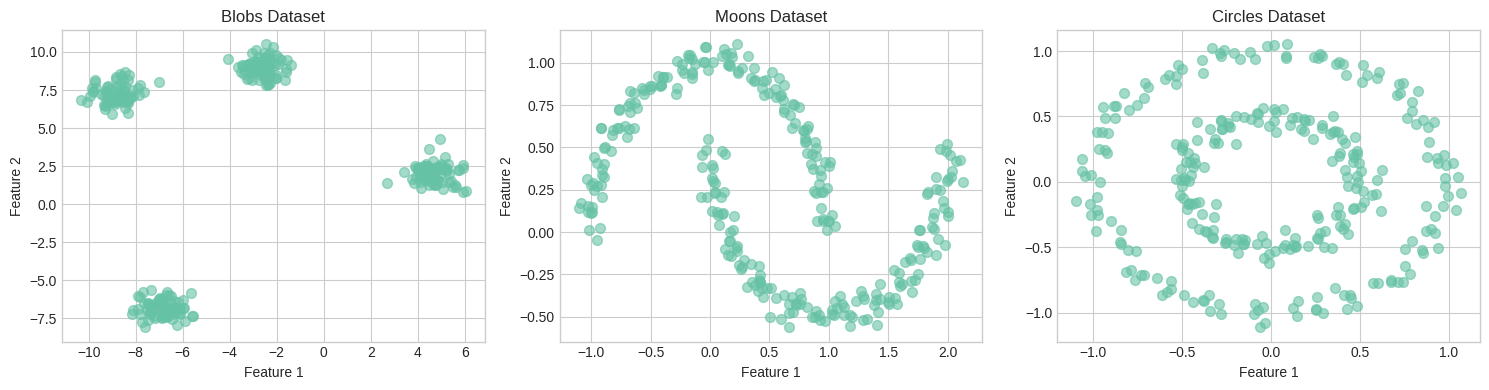

## Part 2: K-means Clustering

K-means is a popular clustering algorithm that partitions data into K clusters by minimizing within-cluster variance.

### How K-means Works:
1. Initialize K centroids randomly
2. Assign each point to the nearest centroid
3. Update centroids as the mean of assigned points
4. Repeat steps 2-3 until convergence

### Finding Optimal K using Elbow Method

In [ ]:
# TODO: Implement the elbow method
# Test K values from 2 to 10
inertias = []
K_range = range(2, 11)

for k in K_range:
    # Initialize KMeans with k clusters
    kmeans = None  # Replace None with KMeans initialization
    # Fit the model
    None  # Replace None with fit command
    # Append inertia (within-cluster sum of squares)
    inertias.append(None)  # Replace None

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

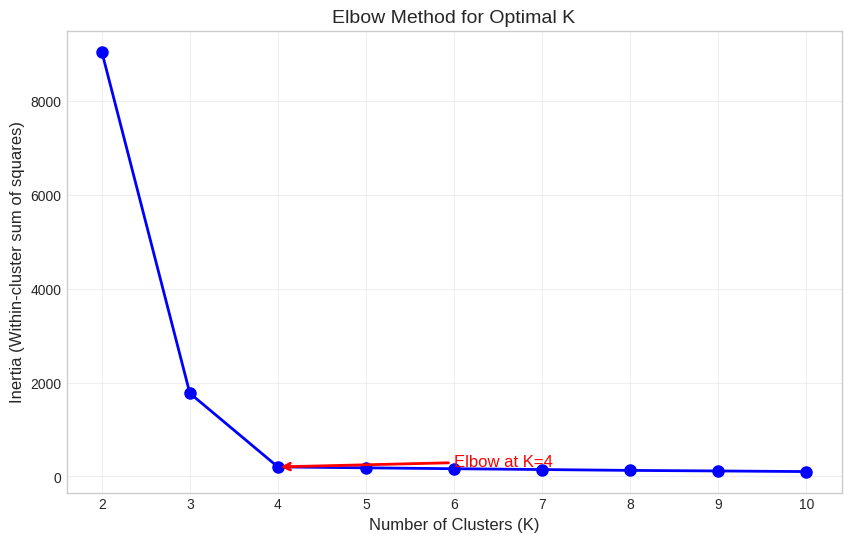

**Question:** Looking at the elbow plot, what value of K would you choose?

**Your Answer:**
_[Write your answer here]_

### Apply K-means to Different Datasets

In [ ]:
# TODO: Apply K-means with K=4 to blobs dataset
kmeans_blobs = None  # Initialize KMeans with n_clusters=4, random_state=42
labels_blobs = None  # Fit and predict labels

# TODO: Apply K-means with K=2 to moons dataset
kmeans_moons = None  # Initialize KMeans
labels_moons = None  # Fit and predict labels

# TODO: Apply K-means with K=2 to circles dataset
kmeans_circles = None  # Initialize KMeans
labels_circles = None  # Fit and predict labels

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results = [
    (X_blobs, labels_blobs, kmeans_blobs, 'Blobs'),
    (X_moons, labels_moons, kmeans_moons, 'Moons'),
    (X_circles, labels_circles, kmeans_circles, 'Circles')
]

for idx, (X, labels, model, title) in enumerate(results):
    axes[idx].scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', alpha=0.6)
    if model is not None:
        axes[idx].scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
                         marker='X', s=200, c='red', edgecolors='black', linewidths=2,
                         label='Centroids')
    axes[idx].set_title(f'K-means on {title}')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')
    axes[idx].legend()

plt.tight_layout()
plt.show()

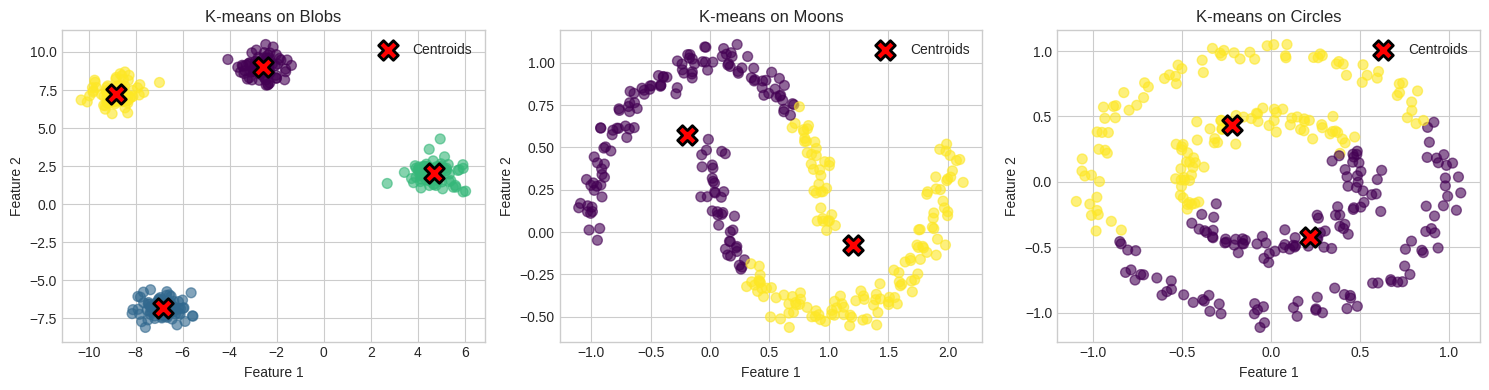

**Question:** Which dataset does K-means struggle with? Why?

**Your Answer:**
_[Write your answer here]_

## Part 3: DBSCAN (Density-Based Spatial Clustering)

DBSCAN groups points that are closely packed together, marking points in low-density regions as outliers.

### Key Parameters:
- **eps**: Maximum distance between two points to be considered neighbors
- **min_samples**: Minimum number of points to form a dense region

### Advantages:
- Can find arbitrarily shaped clusters
- Robust to outliers
- Doesn't require specifying number of clusters

In [ ]:
# TODO: Apply DBSCAN to all three datasets
# For blobs: eps=0.5, min_samples=5
dbscan_blobs = None  # Initialize DBSCAN
labels_dbscan_blobs = None  # Fit and get labels

# For moons: eps=0.3, min_samples=5
dbscan_moons = None  # Initialize DBSCAN
labels_dbscan_moons = None  # Fit and get labels

# For circles: eps=0.2, min_samples=5
dbscan_circles = None  # Initialize DBSCAN
labels_dbscan_circles = None  # Fit and get labels

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results = [
    (X_blobs, labels_dbscan_blobs, 'Blobs'),
    (X_moons, labels_dbscan_moons, 'Moons'),
    (X_circles, labels_dbscan_circles, 'Circles')
]

for idx, (X, labels, title) in enumerate(results):
    # -1 labels are outliers in DBSCAN
    unique_labels = set(labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = 'black'  # Outliers in black
        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        axes[idx].scatter(xy[:, 0], xy[:, 1], s=50, c=[col], alpha=0.6,
                         edgecolors='black' if k == -1 else 'none')

    axes[idx].set_title(f'DBSCAN on {title}')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

    # Count outliers
    n_outliers = list(labels).count(-1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    axes[idx].text(0.05, 0.95, f'Clusters: {n_clusters}\nOutliers: {n_outliers}',
                   transform=axes[idx].transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

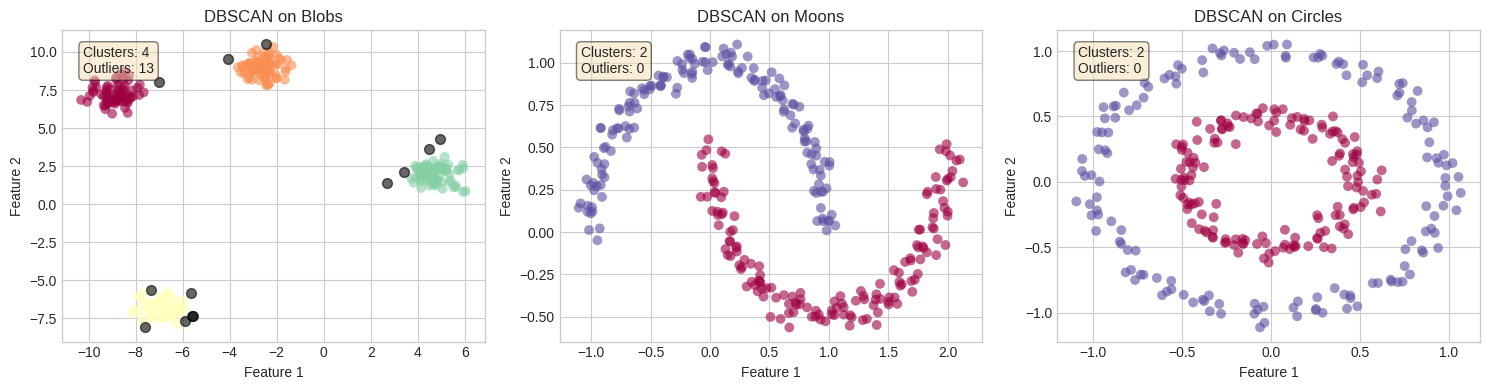

**Question:** Compare DBSCAN's performance to K-means. On which datasets does DBSCAN perform better?

**Your Answer:**
_[Write your answer here]_

## Part 4: Hierarchical Clustering

Hierarchical clustering creates a tree of clusters (dendrogram) that can be cut at different levels.

### Two Approaches:
- **Agglomerative (Bottom-up)**: Start with individual points, merge closest pairs
- **Divisive (Top-down)**: Start with one cluster, recursively split

In [ ]:
# TODO: Apply Agglomerative Clustering to blobs dataset
# Use n_clusters=4, linkage='ward'
hierarchical = None  # Initialize AgglomerativeClustering
labels_hierarchical = None  # Fit and get labels

# Visualize the clustering result
plt.figure(figsize=(10, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_hierarchical, s=50, cmap='viridis', alpha=0.6)
plt.title('Hierarchical Clustering on Blobs Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster')
plt.show()

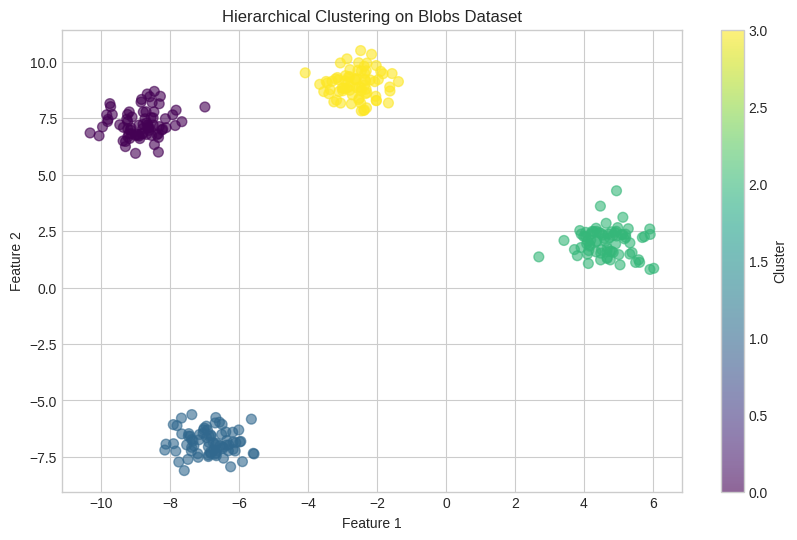

### Visualize the Dendrogram

A dendrogram shows how clusters are merged at each step.

In [ ]:
# Create linkage matrix for dendrogram
# Using only first 100 samples for clarity
X_sample = X_blobs[:100]
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=12)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.axhline(y=5, color='r', linestyle='--', label='Cut line for 4 clusters')
plt.legend()
plt.show()

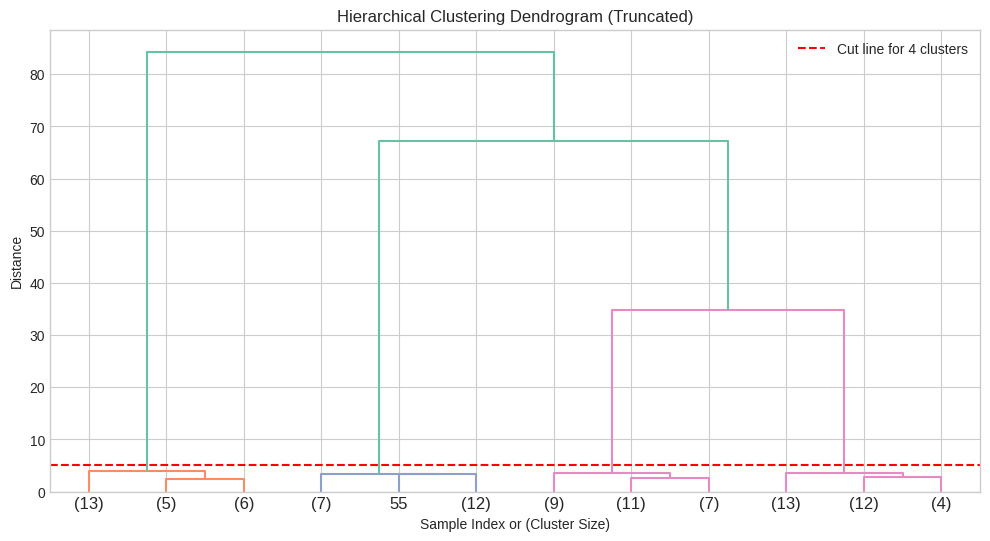

## Part 5: Clustering Evaluation Metrics

Let's compare all algorithms using multiple metrics.

In [ ]:
# TODO: Calculate evaluation metrics for all methods on blobs dataset
def evaluate_clustering(X, labels, method_name):
    """Calculate and display clustering metrics"""
    # Filter out noise points (-1) for DBSCAN
    mask = labels != -1
    X_filtered = X[mask]
    labels_filtered = labels[mask]

    if len(set(labels_filtered)) < 2:
        print(f"{method_name}: Not enough clusters for evaluation")
        return None

    # TODO: Calculate three metrics
    # Hint: Use silhouette_score, davies_bouldin_score, calinski_harabasz_score
    silhouette = None  # Replace None
    davies_bouldin = None  # Replace None
    calinski = None  # Replace None

    return {
        'Method': method_name,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin,
        'Calinski-Harabasz Score': calinski
    }

# Evaluate all methods
results_list = []
results_list.append(evaluate_clustering(X_blobs, labels_blobs, 'K-means'))
results_list.append(evaluate_clustering(X_blobs, labels_dbscan_blobs, 'DBSCAN'))
results_list.append(evaluate_clustering(X_blobs, labels_hierarchical, 'Hierarchical'))

# Create comparison table
results_df = pd.DataFrame([r for r in results_list if r is not None])
print("\n=== Clustering Performance on Blobs Dataset ===")
print(results_df.to_string(index=False))
print("\nNote:")
print("- Silhouette Score: Higher is better (range: -1 to 1)")
print("- Davies-Bouldin Index: Lower is better")
print("- Calinski-Harabasz Score: Higher is better")

## Part 6: Comprehensive Comparison

Let's create a side-by-side comparison of all three algorithms on all datasets.

In [ ]:
# Create comprehensive comparison plot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

datasets_info = [
    ('Blobs', X_blobs, labels_blobs, labels_dbscan_blobs, labels_hierarchical),
    ('Moons', X_moons, labels_moons, labels_dbscan_moons, None),
    ('Circles', X_circles, labels_circles, labels_dbscan_circles, None)
]

for row, (name, X, kmeans_labels, dbscan_labels, hier_labels) in enumerate(datasets_info):
    # K-means
    axes[row, 0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, s=30, cmap='viridis', alpha=0.6)
    axes[row, 0].set_title(f'K-means on {name}')
    axes[row, 0].set_ylabel('Feature 2')

    # DBSCAN
    unique_labels = set(dbscan_labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = 'black'
        mask = (dbscan_labels == k)
        axes[row, 1].scatter(X[mask, 0], X[mask, 1], s=30, c=[col], alpha=0.6)
    axes[row, 1].set_title(f'DBSCAN on {name}')

    # Hierarchical (only for blobs)
    if hier_labels is not None:
        axes[row, 2].scatter(X[:, 0], X[:, 1], c=hier_labels, s=30, cmap='viridis', alpha=0.6)
        axes[row, 2].set_title(f'Hierarchical on {name}')
    else:
        axes[row, 2].text(0.5, 0.5, 'Not Applied', ha='center', va='center',
                         transform=axes[row, 2].transAxes, fontsize=14)
        axes[row, 2].set_title(f'Hierarchical on {name}')

# Set x-labels for bottom row
for col in range(3):
    axes[2, col].set_xlabel('Feature 1')

plt.tight_layout()
plt.show()

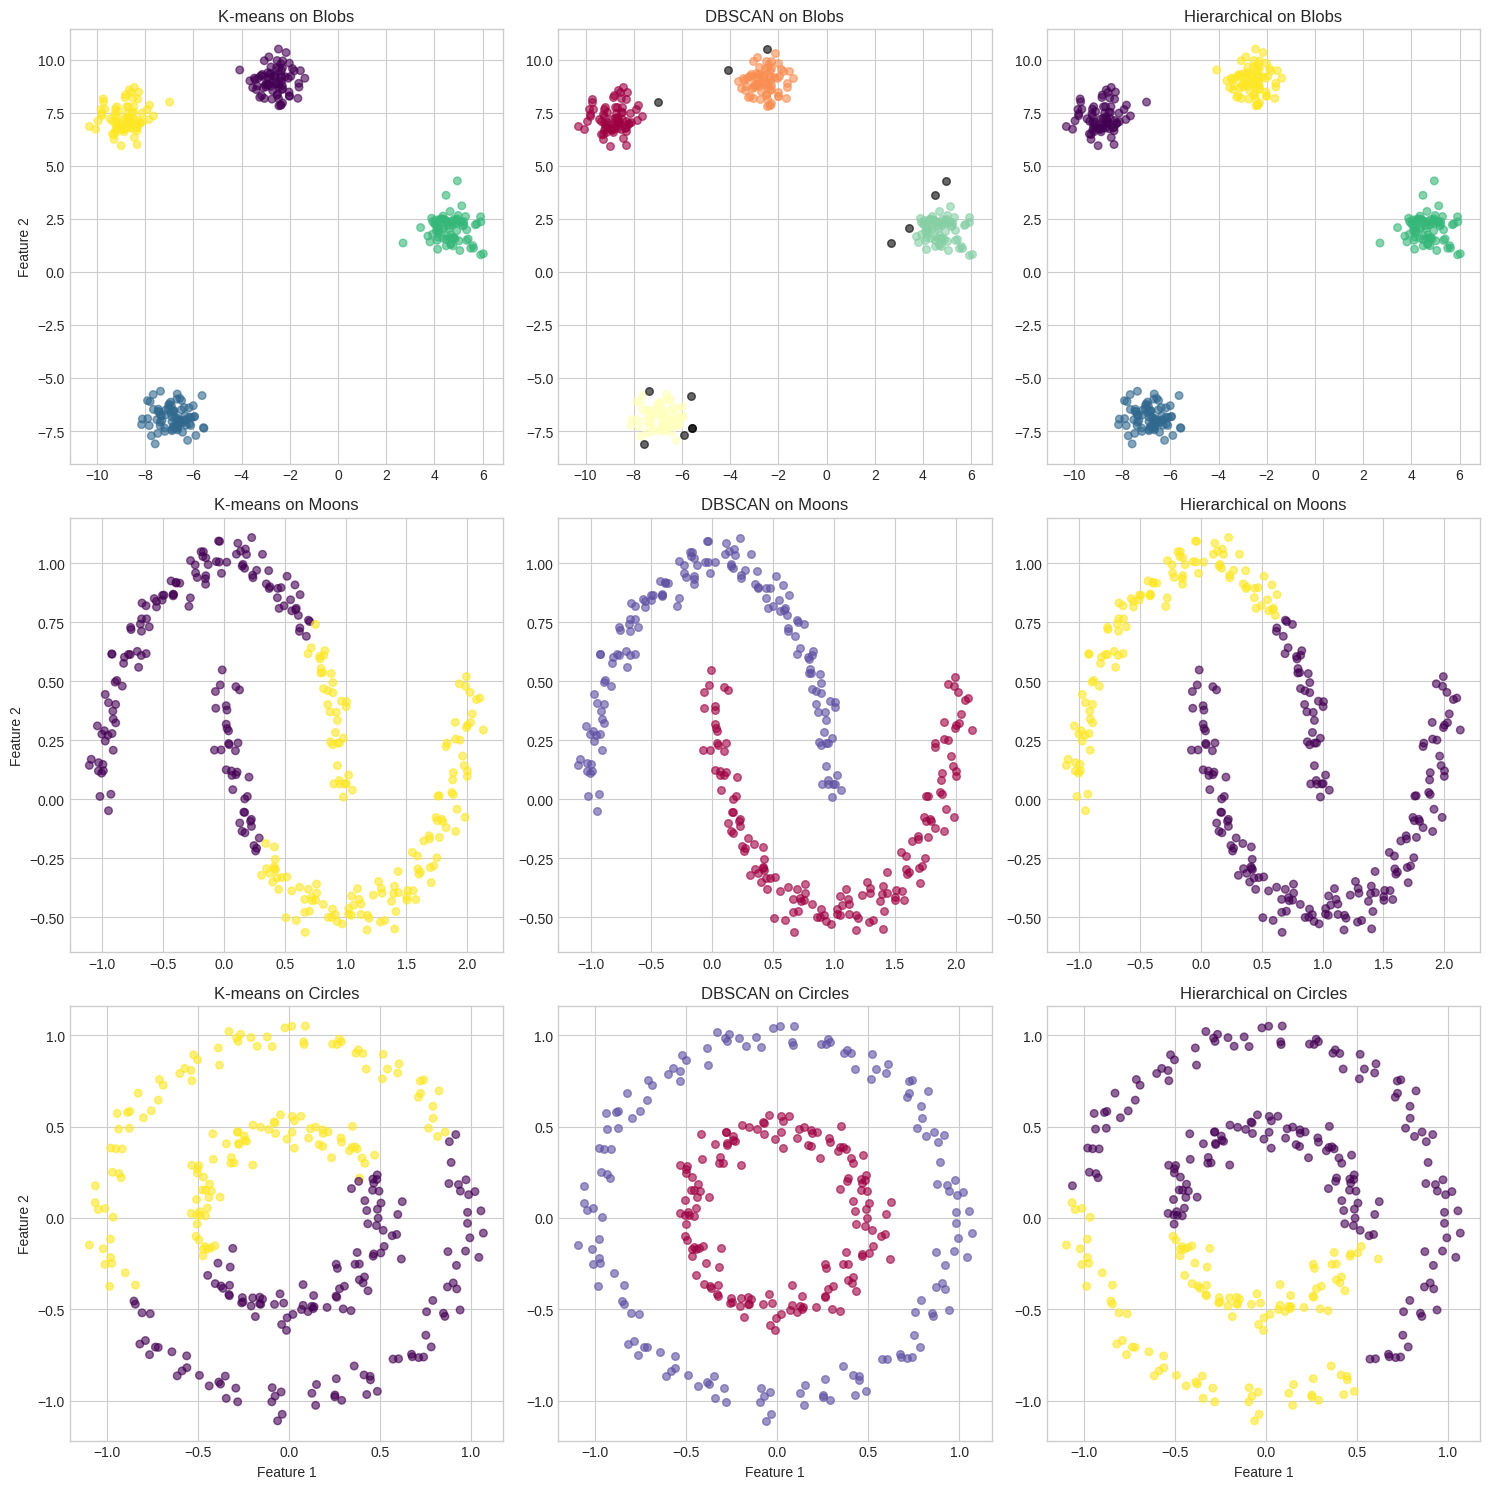

## Part 7: Real-World Application - Customer Segmentation

Let's apply clustering to a realistic scenario using the Iris dataset as a proxy for customer features.

In [ ]:
# Load iris dataset
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Standardize the data
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Apply PCA for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

print(f"Dataset shape: {X_iris.shape}")
print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

In [ ]:
# TODO: Apply all three clustering methods to iris dataset
# Use the PCA-transformed data for visualization

# K-means with 3 clusters
kmeans_iris = None  # Initialize and fit
labels_kmeans_iris = None  # Get labels

# DBSCAN with eps=0.5, min_samples=5
dbscan_iris = None  # Initialize and fit
labels_dbscan_iris = None  # Get labels

# Hierarchical with 3 clusters
hier_iris = None  # Initialize and fit
labels_hier_iris = None  # Get labels

# Create comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

# True labels
axes[0].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris, s=50, cmap='viridis', alpha=0.6)
axes[0].set_title('True Species Labels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# K-means
axes[1].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=labels_kmeans_iris, s=50, cmap='viridis', alpha=0.6)
axes[1].set_title('K-means Clustering')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# DBSCAN
axes[2].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=labels_dbscan_iris, s=50, cmap='viridis', alpha=0.6)
axes[2].set_title('DBSCAN Clustering')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

# Hierarchical
axes[3].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=labels_hier_iris, s=50, cmap='viridis', alpha=0.6)
axes[3].set_title('Hierarchical Clustering')
axes[3].set_xlabel('PC1')
axes[3].set_ylabel('PC2')

plt.tight_layout()
plt.show()

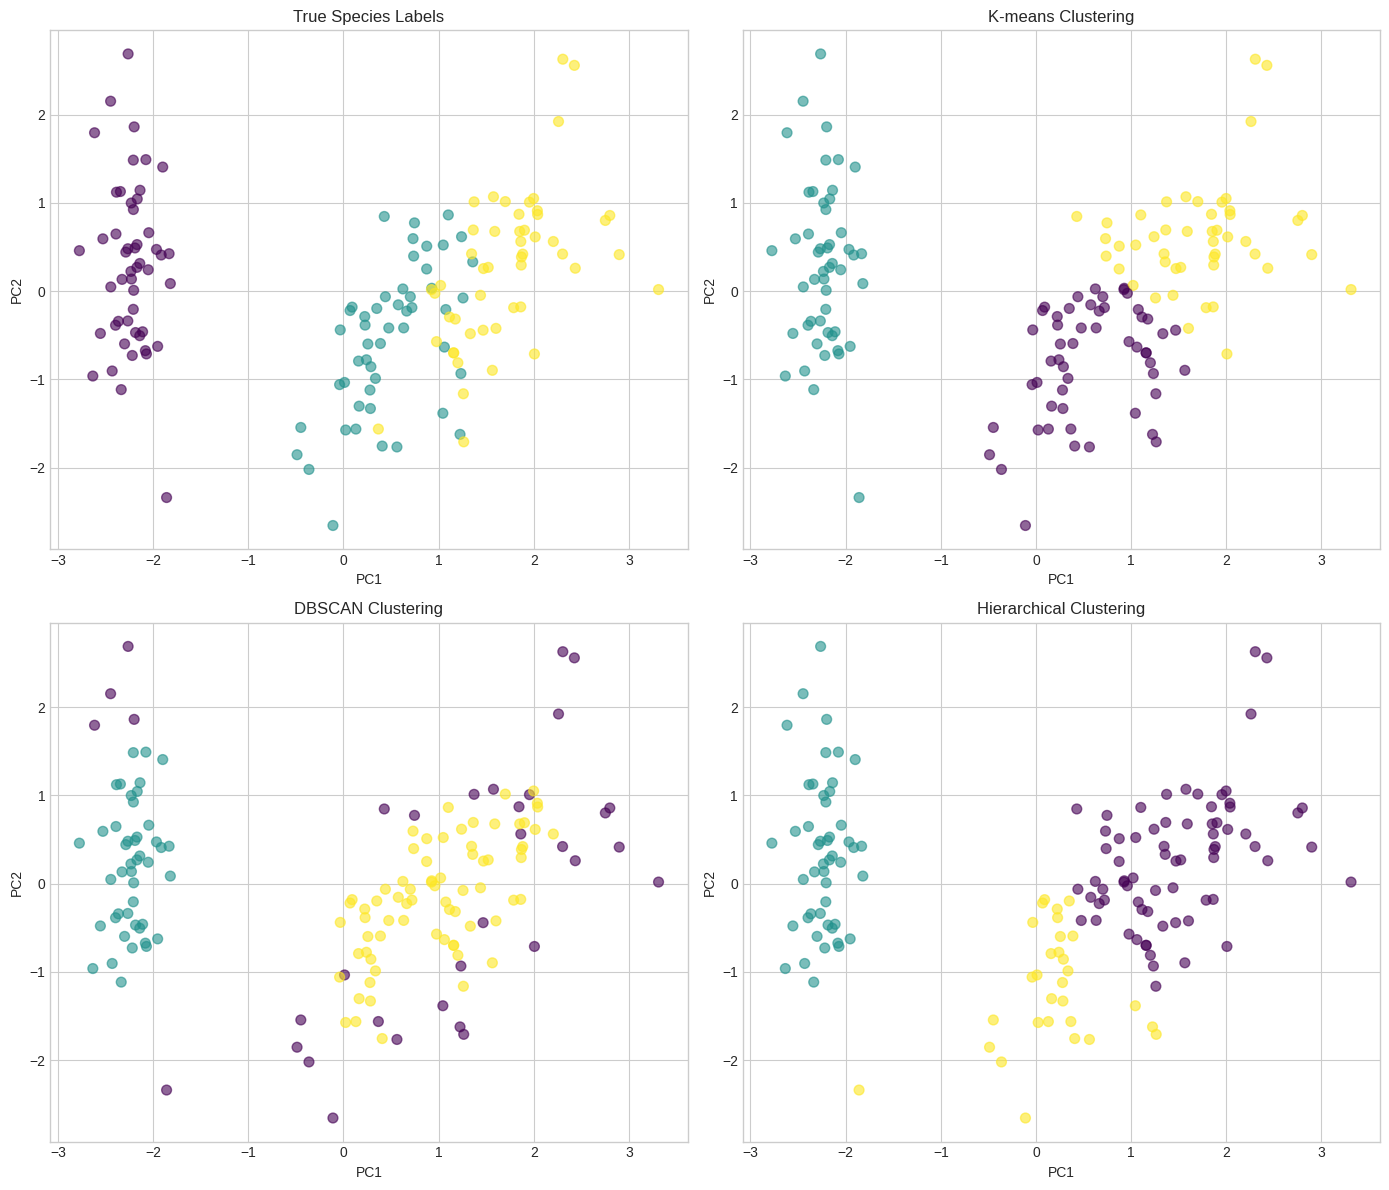

## Part 8: Reflection Questions

Answer the following questions based on your understanding:

1. **What are the main differences between K-means and DBSCAN?**
   
   _[Your answer here]_

2. **When would you prefer DBSCAN over K-means?**
   
   _[Your answer here]_

3. **What is the advantage of hierarchical clustering?**
   
   _[Your answer here]_

4. **How do you choose the right clustering algorithm for your problem?**
   
   _[Your answer here]_

5. **What are the limitations of each clustering method?**
   
   _[Your answer here]_

## Part 9: Summary Table

Complete the following comparison table:

| Criterion | K-means | DBSCAN | Hierarchical |
|-----------|---------|--------|-------------|
| Need to specify K? | | | |
| Handles outliers? | | | |
| Works with non-spherical clusters? | | | |
| Scalability | | | |
| Best use case | | | |

## Bonus Challenge (Optional)

Try clustering on a dataset of your choice or experiment with different parameters!

In [ ]:
# Your code here
